# NFL Draft Prediction - Competition Submission on June 19, 2026
## GCI World 2026 April
### Student: Shaheer Shamsi (shaheer.shamsi16@gmail.com) (omnicampus: "shaheer-shamsi")
### drive: https://drive.google.com/drive/u/0/folders/1fWs44bdPfELBC0lQFZDzgc3a2zPZ3t4h

**Solution:**
- performance-weighted averaging on 5-Fold Cross-Validation
- Use of feature engineering: explosiveness index, BMI, power:weight ratios,  speed and agility composite, school frequency, school target encoding and  missing data indicator
- LightGBM, XGBoost, CatBoost, Random Forest ensembling method
- Validation AUC: ~0.84 - 0.85
- MODEL SUMMARY: catboost: AUC = 0.8517, rf: AUC = 0.8464, xgb: AUC = 0.8412, lgbm: AUC = 0.8391


# [Baseline] Data Analysis Competition: NFL Draft Prediction

In this notebook, you will build a **baseline model** for the task of predicting whether a player will be selected in the NFL Draft (**Drafted**) based on sports performance test results and player information.

A baseline model is a simple initial model built for a given machine learning task. It serves as a starting point for further model development and performance improvements.

By running this notebook from top to bottom, you will generate a prediction file that can be submitted successfully.


## Table of Contents
1. Setup

2. Load the Data

3. Data Analysis & EDA

4. Preprocessing

5. Baseline Model

6. Hypothesis & Feature Engineering

7. Create the Submission File

8. Next Steps


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

!pip install lightgbm xgboost catboost -q #needed
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import warnings
np.random.seed(42) #for reproducibility

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


## 2.Load the data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# IMPORTANT: Change this path to where you uploaded the competition folder
%cd "/content/drive/MyDrive/GCI_competition/competition"

/content/drive/MyDrive/GCI_competition/competition


Next, we need to navigate to where the `competition` folder is located

**IMPORTANT**:<br>
Change the path in the `%cd` command below to match the folder where this notebook is saved on Google Drive by **replacing "WhereThisNotebookIsLocated" with your actual folder path**.

Examples:
- You uploaded `competition` folder directly under MyDrive (the default folder when you open Google Drive)
    - Change to "/<wbr>content/drive/MyDrive/competition"
- You uploaded `competition` folder inside a folder named `00_GCIGlobal` under MyDrive
    - Change to "/<wbr>content/drive/MyDrive/00_GCIGlobal/competition"

You can easily locate your notebook's directory by:
1. Open the Files panel on the left side of Colab
2. Navigate through the "drive" and "MyDrive" folders until you find your notebook's folders
3. Click the more actions icon (three vertical dots, $\vdots$) next to the folder name
4. Select the option "Copy path"

### 2.2 Data Overview
Run the cell to load the dataset as `pd.DataFrame`.

**IMPORTANT:**<br>
**When you make modifications to preprocessing or model training, always make sure to run all cells from this cell.**

In [4]:
PATH = Path.cwd() / "input"

train = pd.read_csv(PATH / "train.csv")
test = pd.read_csv(PATH / "test.csv")
sample_sub = pd.read_csv(PATH / "sample_submission.csv")

print(f"train: {train.shape}, test: {test.shape}, sample_sub: {sample_sub.shape}")
train.head()

train: (2781, 16), test: (696, 15), sample_sub: (696, 2)


,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


## 3.Data Analysis & EDA

**EDA (Exploratory Data Analysis)** is an essential step for understanding the structure and characteristics of your data before building a model.

At this stage, you explore trends and patterns in the dataset, as well as **outliers**, **missing values**, and **imbalanced distributions**. For example, some variables may contain extreme values, or the data may be heavily skewed toward specific categories. Identifying these characteristics helps you find potential issues that could hurt performance and uncover features that may be useful for prediction.

By performing EDA, you can detect and address problems early—such as “training fails due to missing values” or “the model becomes unstable because of outliers.” This reduces rework later and enables more efficient preprocessing and feature engineering.

Insights from EDA also inform later decisions, including model selection and hyperparameter tuning. In machine learning competitions, EDA is often a key process for improving final scores.

Drafted (1): 64.8%
Not Drafted (0): 35.2%


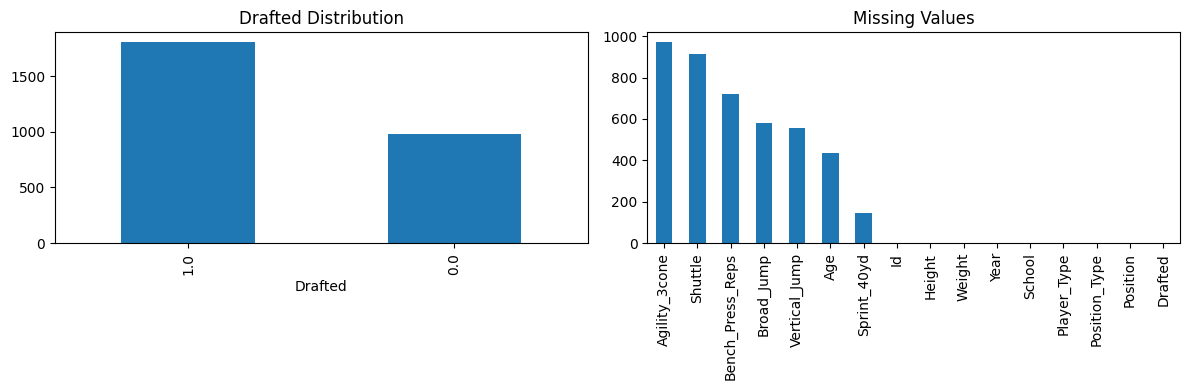

In [5]:
#target dist
drafted_pct = train['Drafted'].value_counts(normalize=True) * 100
print(f"Drafted (1): {drafted_pct.get(1, 0):.1f}%")
print(f"Not Drafted (0): {drafted_pct.get(0, 0):.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train['Drafted'].value_counts().plot(kind='bar', ax=axes[0], title='Drafted Distribution')
train.isnull().sum().sort_values(ascending=False).plot(kind='bar', ax=axes[1], title='Missing Values')
plt.tight_layout()
plt.show()

In [6]:
#corelation
numeric_cols = train.select_dtypes(include=['number']).drop(columns=['Id'])
corr_with_target = numeric_cols.corr()['Drafted'].drop('Drafted').sort_values(ascending=False)
print("Correlation with Drafted:")
print(corr_with_target)

Correlation with Drafted:
Bench_Press_Reps    0.132244
Broad_Jump          0.112673
Vertical_Jump       0.109406
Weight              0.071024
Height              0.046875
Year               -0.024563
Agility_3cone      -0.073372
Shuttle            -0.087949
Sprint_40yd        -0.112430
Age                -0.133055
Name: Drafted, dtype: float64


### 3.1 Checking Missing Values

First, let's check for missing values. This is an essential step in machine-learning-based data analysis, because most machine learning models cannot train on or make predictions from data that contains missing values, and will raise an error.

In [7]:
train.isnull().sum()

,0
Id,0
Year,0
Age,435
School,0
Height,0
Weight,0
Sprint_40yd,145
Vertical_Jump,554
Bench_Press_Reps,721
Broad_Jump,581


In [8]:
test.isnull().sum()

,0
Id,0
Year,0
Age,115
School,0
Height,0
Weight,0
Sprint_40yd,29
Vertical_Jump,143
Bench_Press_Reps,184
Broad_Jump,147


We can see that the training data contains **2,781 rows** and **16 columns**, while the test data contains **696 rows** and **15 columns**.
The test data has one fewer column because it does not include the target variable to be predicted.

In [9]:
train.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2781 non-null   int64  
 1   Year              2781 non-null   int64  
 2   Age               2346 non-null   float64
 3   School            2781 non-null   object 
 4   Height            2781 non-null   float64
 5   Weight            2781 non-null   float64
 6   Sprint_40yd       2636 non-null   float64
 7   Vertical_Jump     2227 non-null   float64
 8   Bench_Press_Reps  2060 non-null   float64
 9   Broad_Jump        2200 non-null   float64
 10  Agility_3cone     1811 non-null   float64
 11  Shuttle           1869 non-null   float64
 12  Player_Type       2781 non-null   object 
 13  Position_Type     2781 non-null   object 
 14  Position          2781 non-null   object 
 15  Drafted           2781 non-null   float64
dtypes: float64(10), int64(2), object(4)
memory

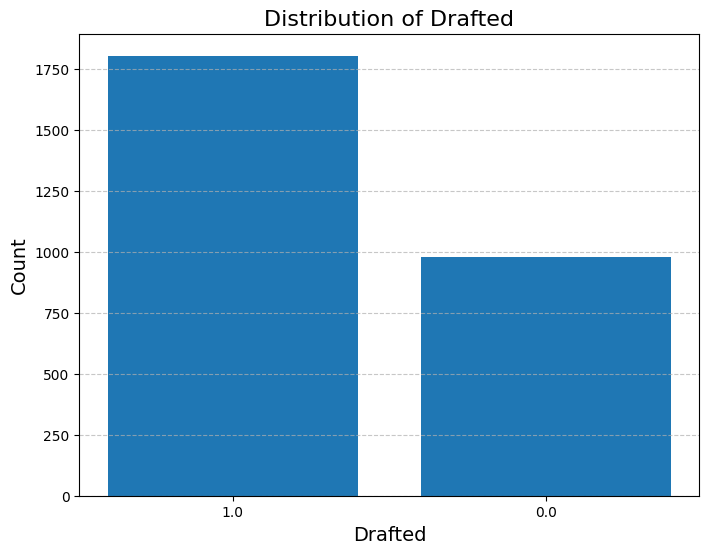

In [11]:
drafted_counts = train['Drafted'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(drafted_counts.index.astype(str), drafted_counts.values)
plt.title('Distribution of Drafted', fontsize=16)
plt.xlabel('Drafted', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [12]:
drafted_percentage = train['Drafted'].value_counts(normalize=True) * 100

print(f"Percentage of 0: {drafted_percentage.get(0, 0):.2f}%")
print(f"Percentage of 1: {drafted_percentage.get(1, 0):.2f}%")

Percentage of 0: 35.17%
Percentage of 1: 64.83%


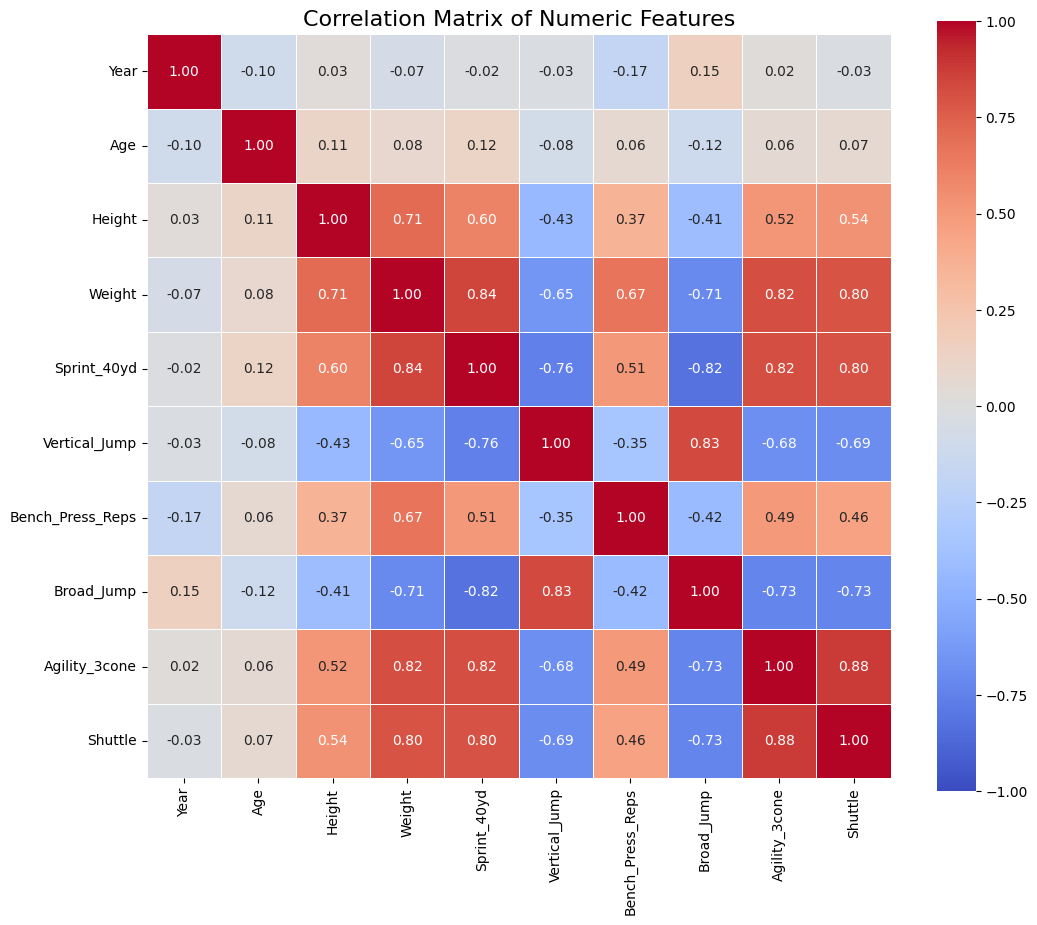

In [13]:
# Extract numeric columns (excluding the 'Id' and ''Drafted' columns)
numeric_cols = train.select_dtypes(include=['number']).drop(['Id', 'Drafted'], axis=1)

# Compute the correlation matrix
corr_matrix = numeric_cols.corr()

# Plot a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

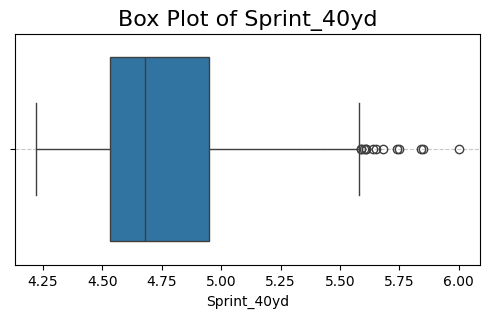

In [14]:
# Plot a boxplot
plt.figure(figsize=(6, 3))
sns.boxplot(x=train['Sprint_40yd'])

plt.title('Box Plot of Sprint_40yd', fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [15]:
# Extract categorical features
categorical_cols = train.select_dtypes(include=['object', 'category']).columns

# Get the number of unique categories in each column
levels_count = {col: train[col].nunique() for col in categorical_cols}

for col, count in levels_count.items():
    print(f"{col}: {count} levels")


School: 236 levels
Player_Type: 3 levels
Position_Type: 7 levels
Position: 20 levels


## Feature Engineering

In [16]:
def create_features(df):
    df = df.copy()

    #explosiveness index
    df['Explosiveness'] = df['Vertical_Jump'] + df['Broad_Jump']
    #bmi
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)
    df['Weight_Height'] = df['Weight'] / df['Height']

    #power:weight
    df['Power_Weight'] = df['Vertical_Jump'] / df['Weight']
    df['Broad_Weight'] = df['Broad_Jump'] / df['Weight']
    df['Strength_Weight'] = df['Bench_Press_Reps'] / df['Weight'] * 100

    #speed and agility composite
    df['Speed_Agility'] = df['Sprint_40yd'] + df['Agility_3cone']
    df['Speed_Shuttle'] = df['Sprint_40yd'] + df['Shuttle']
    df['Sprint_Height'] = df['Sprint_40yd'] / df['Height']


    #school frequency
    df['School_Freq'] = df['School'].map(df['School'].value_counts())

    #NULL (players who skip tests)
    perf_cols = ['Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'Age']
    df['Missing_Count'] = df[perf_cols].isnull().sum(axis=1)


    return df

train = create_features(train)
test = create_features(test)
print(f"After feature engineering - Train: {train.shape}, Test: {test.shape}")

After feature engineering - Train: (2781, 27), Test: (696, 26)


### [Next Steps]

EDA is open-ended; here are some directions you can take next:

- Examine the relationship between each numerical feature and the target with grouped boxplots (`sns.boxplot(x='Drafted', y=col, ...)`).
- Cross-tabulate categorical features against **Drafted** to see which categories have a high or low draft rate.
- Investigate the **School** column more carefully — for example, group schools by conference or region and check the draft rate per group.
- Look for outliers in other numerical columns (e.g. **Bench_Press_Reps**, **Vertical_Jump**) and decide how to handle them.

## 4.Preprocessing

Here, we will conduct the preprocessing and create new features based on what we have learned in the preceding visualization and analysis. We will perform **missing value imputation** and **encoding**.

In [17]:
cat_cols = ['Player_Type', 'Position_Type', 'Position']
label_encoders = {}
for c in cat_cols:
    label_encoders[c] = LabelEncoder()
    train[c] = label_encoders[c].fit_transform(train[c].astype(str))
    test[c] = label_encoders[c].transform(test[c].astype(str))

school_means = train.groupby('School')['Drafted'].mean()
global_mean = train['Drafted'].mean()
train['School_Target'] = train['School'].map(school_means)
test['School_Target'] = test['School'].map(school_means).fillna(global_mean)

X = train.drop(columns=['Id', 'Drafted', 'School'])
y = train['Drafted']
X_test = test.drop(columns=['Id', 'School'])

#impute with train mean
for col in X.columns:
    if X[col].isnull().any():
        mean_val = X[col].mean()
        X[col] = X[col].fillna(mean_val)
        X_test[col] = X_test[col].fillna(mean_val)

print(f"X: {X.shape}, y: {y.shape}, X_test: {X_test.shape}")
print(f"\nFeatures ({len(X.columns)}): {list(X.columns)}")
print(f"\nMissing values remaining - Train: {X.isnull().sum().sum()}, Test: {X_test.isnull().sum().sum()}")

X: (2781, 25), y: (2781,), X_test: (696, 25)

Features (25): ['Year', 'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'Player_Type', 'Position_Type', 'Position', 'Explosiveness', 'BMI', 'Weight_Height', 'Power_Weight', 'Broad_Weight', 'Strength_Weight', 'Speed_Agility', 'Speed_Shuttle', 'Sprint_Height', 'School_Freq', 'Missing_Count', 'School_Target']

Missing values remaining - Train: 0, Test: 0


## 5. Train Ensemble Model (LightGBM + XGBoost + CatBoost + RandomForest)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'lgbm': LGBMClassifier(
        n_estimators=1000, learning_rate=0.03, max_depth=6,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.1, random_state=42, verbose=-1
    ),
    'xgb': XGBClassifier(
        n_estimators=1000, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.1, random_state=42,
        eval_metric='auc', verbosity=0
    ),
    'catboost': CatBoostClassifier(
        iterations=1000, learning_rate=0.03, depth=6,
        random_seed=42, verbose=0
    ),
    'rf': RandomForestClassifier(
        n_estimators=500, max_depth=10, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    )
}

all_test_preds = {}
all_val_scores = {}

for name, model in models.items():
    print(f'\nTraining: {name}')
    test_preds = []
    val_scores = []
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        model.fit(X_train, y_train)
        y_valid_pred = model.predict_proba(X_valid)[:, 1]
        auc = roc_auc_score(y_valid, y_valid_pred)
        val_scores.append(auc)
        test_preds.append(model.predict_proba(X_test)[:, 1])
        print(f'  Fold {fold+1} AUC: {auc:.4f}')
    mean_auc = np.mean(val_scores)
    print(f'  >>> Mean AUC: {mean_auc:.4f}')
    all_test_preds[name] = np.mean(test_preds, axis=0)
    all_val_scores[name] = mean_auc

print(f'\n{"="*50}')
print('MODEL SUMMARY:')
for name, score in sorted(all_val_scores.items(), key=lambda x: -x[1]):
    print(f'  {name:>10s}: AUC = {score:.4f}')


Training: lgbm
  Fold 1 AUC: 0.8375
  Fold 2 AUC: 0.8663
  Fold 3 AUC: 0.8463
  Fold 4 AUC: 0.7916
  Fold 5 AUC: 0.8537
  >>> Mean AUC: 0.8391

Training: xgb
  Fold 1 AUC: 0.8382
  Fold 2 AUC: 0.8651
  Fold 3 AUC: 0.8459
  Fold 4 AUC: 0.8047


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



  Fold 5 AUC: 0.8521
  >>> Mean AUC: 0.8412

Training: catboost
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_780/715236867.py", line 35, in <cell line: 0>
    model.fit(X_train, y_train)
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", line 5547, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", line 2716, in _fit
    self._train(
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", line 1824, in _train
    self._object._train(train_pool, test_pool, params, allow_clear_pool, init_model._object if init_model else None)
  File "_catboost.pyx", line 5430, in _catboost._CatBoost._train
  File "_catboost.pyx", line 5479, 

## 6. Feature Importance

In [ ]:
#feature importance from RF model
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': models['rf'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp, x='Importance', y='Feature')
plt.title('Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

## 7. Create Submission File

### 7.1 Predicting on the test data
We found in Sections 5 and 6 that the best model was Random Forest model with BMI column added. Therefore, we will use this model to make the final prediction.

If you made any changes and found a better model, you will need to change the code below accordingly.

In [ ]:
#weighted average (validation AUC)
total_score = sum(all_val_scores.values())
weights = {name: score / total_score for name, score in all_val_scores.items()}

print('Ensemble weights:')
for name, w in weights.items():
    print(f'  {name}: {w:.3f}')

final_preds = np.zeros(len(X_test))
for name, preds in all_test_preds.items():
    final_preds += weights[name] * preds

# Save submission
submission = sample_sub.copy()
submission['Drafted'] = final_preds

output_path = Path.cwd() / 'output'
output_path.mkdir(exist_ok=True)
submission.to_csv(output_path / 'submission.csv', index=False)

print(f'\nSubmission saved to output/submission.csv')
print(f'Shape: {submission.shape}')
print(f'\nFirst 10 rows:')
print(submission.head(10))
print(f'\nPrediction statistics:')
print(submission['Drafted'].describe())

### 7.2 Saving the prediction as CSV file [DO NOT CHANGE]
**WARNING**: DO **NOT** CHANGE THE CODES BELOW!!!

In [ ]:
# Running this cell will generate the submission CSV file
submission = pd.read_csv(PATH / 'sample_submission.csv') # Update PATH in needed
submission["Drafted"] = test_pred_proba_mean
submission.to_csv(PATH / 'submission.csv', index=False)

At this point, you have successfully created a prediction CSV file that is ready for submission. Try submitting **submission.csv**.

## 8.Next Steps

In this notebook, we built a baseline model end to end—from preprocessing and feature engineering to model training and evaluation.

From here, you can use this baseline as a foundation and aim for higher accuracy by designing more advanced features and improving the modeling approach. For example, you might explore the following:

- Try different encoding methods for categorical features
- Try alternative missing-value imputation strategies
- Experiment with other models
- Tune model hyperparameters
- Develop additional feature engineering ideas

Let’s work toward a higher score!

## 9.References
- McKinney, W. (2022). Python for Data Analysis: Data Wrangling with pandas, NumPy, and Jupyter (3rd ed.). O'Reilly Media.
This book is a standard reference for data cleaning, handling missing values, data transformation, and feature engineering techniques.

- Alpaydin, E. (2020). Introduction to Machine Learning (4th ed.). MIT Press.
This textbook covers standard machine learning workflows, dimensionality reduction, and combining multiple learners through ensemble methods.

- Google Gemini for search assist and formatting.